# Лабораторная работа №2
### Exploratory Data Analysis

В качестве исходного датасета был выбран `fifa_eda`, предлагаемый по умолчанию и содержащий в себе данные игроков, включённых в спортивный симулятор FIFA 19.

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fifa_df = pd.read_csv('fifa.csv')

fifa_df.sample(10)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
1073,165526,G. Paletta,32,Italy,77,77,Jiangsu Suning FC,5000.0,20.0,Right,3.0,2.0,RCB,2018,2020-01-01,6.250000,176.0,10800.000000
13004,231407,S. Donnellan,21,Republic of Ireland,63,71,Yeovil Town,475.0,1.0,Right,1.0,2.0,CB,2018,2019-01-01,6.000000,152.0,926.000000
4020,184337,Go Yo Han,30,Korea Republic,71,71,FC Seoul,2200.0,6.0,Right,1.0,3.0,RM,2005,2021-01-01,5.583333,143.0,2700.000000
5012,214343,D. Moreno,26,Colombia,70,73,Deportivo de La Coruña,1800.0,2.0,Right,1.0,2.0,CDM,2016,2019-06-30,5.833333,157.0,4585.060806
13782,238036,J. Cejas,20,Argentina,62,76,Estudiantes de La Plata,675.0,2.0,Right,1.0,2.0,CAM,2017,2019-01-01,5.750000,154.0,1400.000000
12015,212468,J. Basulto,26,Mexico,64,67,Guadalajara,475.0,7.0,Right,1.0,2.0,CB,2011,2019-01-01,6.083333,168.0,843.000000
3836,184274,C. Basham,29,England,72,72,Sheffield United,2400.0,10.0,Right,1.0,2.0,RCB,2014,2021-01-01,6.250000,176.0,4600.000000
16573,225986,D. Mottley-Henry,20,England,57,66,Tranmere Rovers,160.0,1.0,Right,1.0,3.0,RM,2016,2023-01-01,5.833333,157.0,312.000000
15797,242163,M. Cavalleri,20,Chile,59,69,Curicó Unido,260.0,1.0,Right,1.0,2.0,ST,2018,2019-01-01,5.500000,139.0,403.000000
17664,245931,G. Vannucchi,22,Italy,53,60,US Salernitana 1919,60.0,1.0,Right,1.0,1.0,GK,2018,2021-01-01,5.833333,170.0,108.000000


С помощью функции `df.info()` ознакомимся с общей информацией о датасете:
- количеством записей;
- столбцами датафрейма;
- типами данных каждого столбца;
- количеством ненулевых значений в каждом стоблце.

In [3]:
fifa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

Замечаем, что в следующих колонках присутствуют пропуски:
- Club (что обусловлено статусом свободного агента у части игроков);
- Value;
- International Reputation;
- Skill Moves;
- Contract Valid Until.

In [4]:
print("Уникальных ID:", fifa_df["ID"].nunique())
print("Повторяющихся ID:", fifa_df["ID"].duplicated().sum())

print("Полных дубликатов строк:", fifa_df.duplicated().sum())

Уникальных ID: 18207
Повторяющихся ID: 0
Полных дубликатов строк: 0


Отмечаем, что дубликаты идентификаторов игроков и в целом записей игроков в данном датасете **отсутствуют.**

## Расширенная обработка пропусков и выбросов

,Пропусков,"Доля, %"
Club,241,1.32
Value,252,1.38
International Reputation,48,0.26
Skill Moves,48,0.26
Contract Valid Until,289,1.59


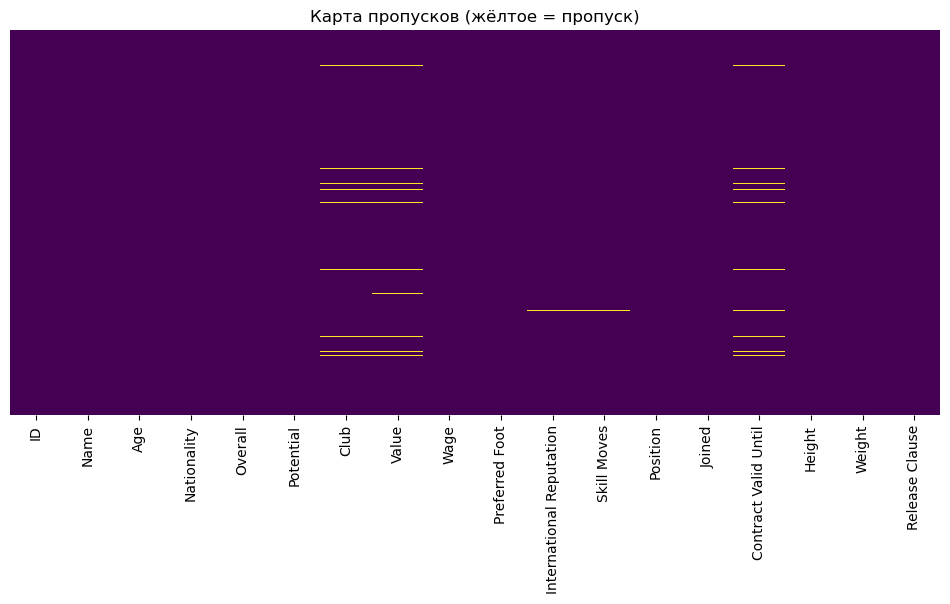

In [5]:
na = fifa_df.isna().sum()
na = na[na > 0].to_frame('Пропусков')
na['Доля, %'] = (na['Пропусков'] / len(fifa_df) * 100).round(2)
display(na)

plt.figure(figsize=(12, 5))
sns.heatmap(fifa_df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков (жёлтое = пропуск)')
plt.show()

## Заполнение пропусков

Правила заполнения:
- Club пропущен у свободных агентов, поэтому заполняем меткой 'Free Agent'.
- Contract Valid Until содержит год в строке. Достаём его регуляркой и заполняем медианой.
- International Reputation и Skill Moves - порядковые признаки (1–5). Заполняем модой.
- Value сильно связан с Overall, поэтому заполняем медианой по группам Overall.

In [6]:
df = fifa_df.copy()

# Club: пропуск = игрок без клуба
df['Club'] = df['Club'].fillna('Free Agent')

# Contract Valid Until: оставляем только год, затем заполняем медианой
df['Contract Valid Until'] = pd.to_numeric(
    df['Contract Valid Until'].astype(str).str.extract(r'(\d{4})')[0])
df['Contract Valid Until'] = df['Contract Valid Until'].fillna(df['Contract Valid Until'].median())

# Value: медиана среди игроков с тем же Overall (стоимость зависит от рейтинга)
df['Value'] = df['Value'].fillna(df.groupby('Overall')['Value'].transform('median'))
df['Value'] = df['Value'].fillna(df['Value'].median())   # если для какого-то Overall медианы нет

# Дискретные признаки 1-5: заполняем модой
for col in ['International Reputation', 'Skill Moves']:
    df[col] = df[col].fillna(df[col].mode()[0])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      18207 non-null  object 
 7   Value                     18207 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18207 non-null  float64
 11  Skill Moves               18207 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

Всего пропусков: 0


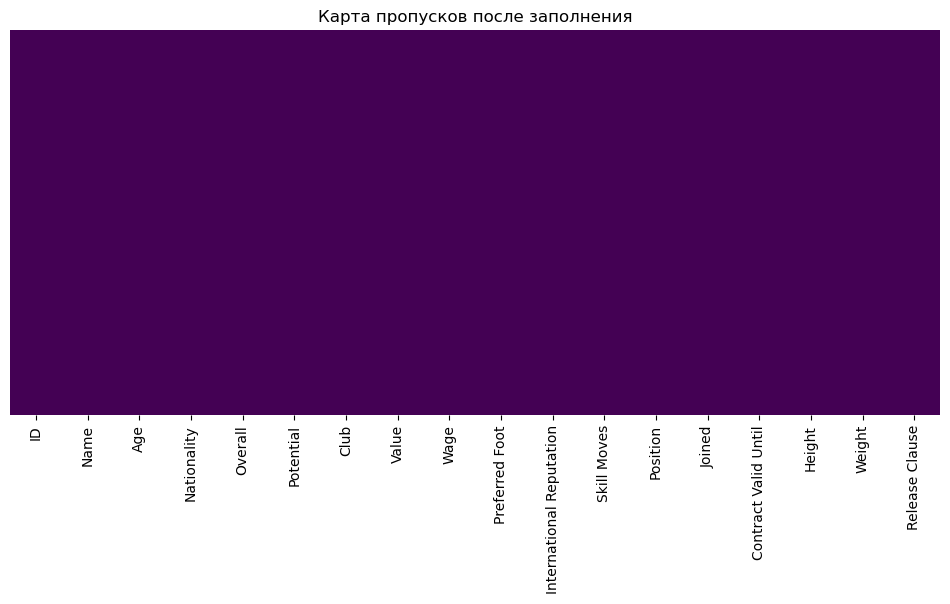

In [7]:
print('Всего пропусков:', df.isna().sum().sum())

plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков после заполнения')
plt.show()

## Работа с выбросами

Для визуализации выбросов используем BoxPlot.

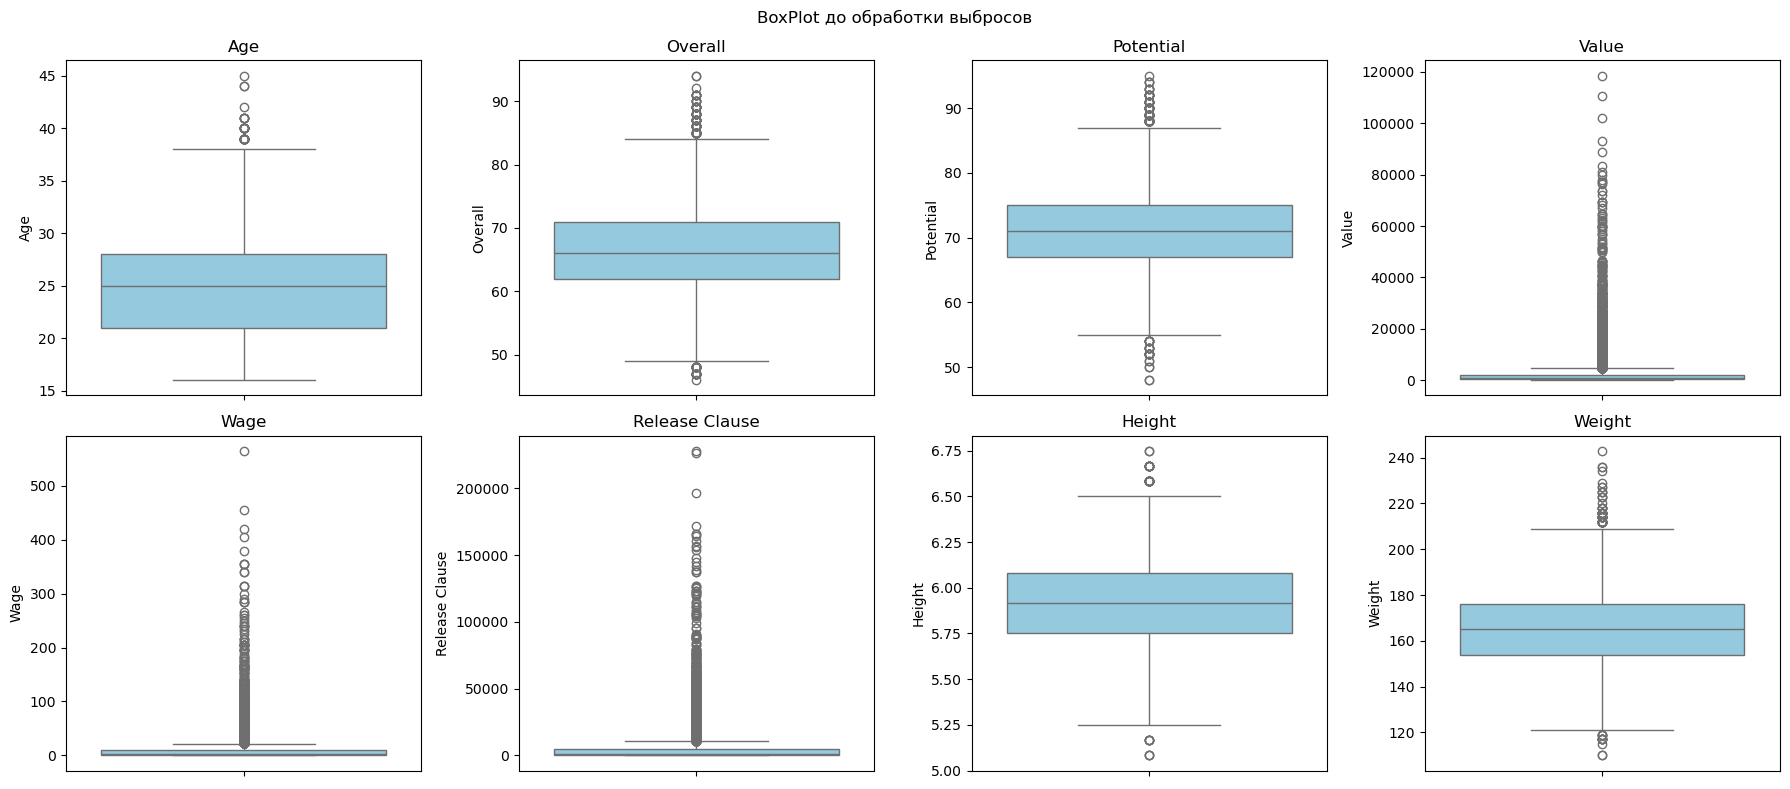

In [8]:
num_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage',
            'Release Clause', 'Height', 'Weight']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.suptitle('BoxPlot до обработки выбросов')
plt.tight_layout()
plt.show()

def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    i = q3 - q1
    return q1 - 1.5 * i, q3 + 1.5 * i

rep = []
for col in num_cols:
    lo, hi = iqr_bounds(df[col])
    rep.append([col, lo, hi, ((df[col] < lo) | (df[col] > hi)).sum()])

`Value`, `Wage` и `Release Clause` имеют сильно скошенное распределение: у небольшого числа звёздных игроков
значения на порядки выше, чем у остальных. Простое обрезание по IQR исказило бы эти признаки, поэтому сначала
применим логарифмирование `log1p`, а затем ограничим значения по IQR. У остальных признаков выбросы
ограничиваются по IQR сразу (метод winsorizing / capping): строки не удаляются, экстремальные значения
заменяются граничными.

In [9]:
# 1. Логарифмирование сильно скошенных денежных признаков
money = ['Value', 'Wage', 'Release Clause']
for col in money:
    df[col] = np.log1p(df[col])

# 2. Ограничение по границам IQR
for col in num_cols:
    lo, hi = iqr_bounds(df[col])
    df[col] = df[col].clip(lo, hi)

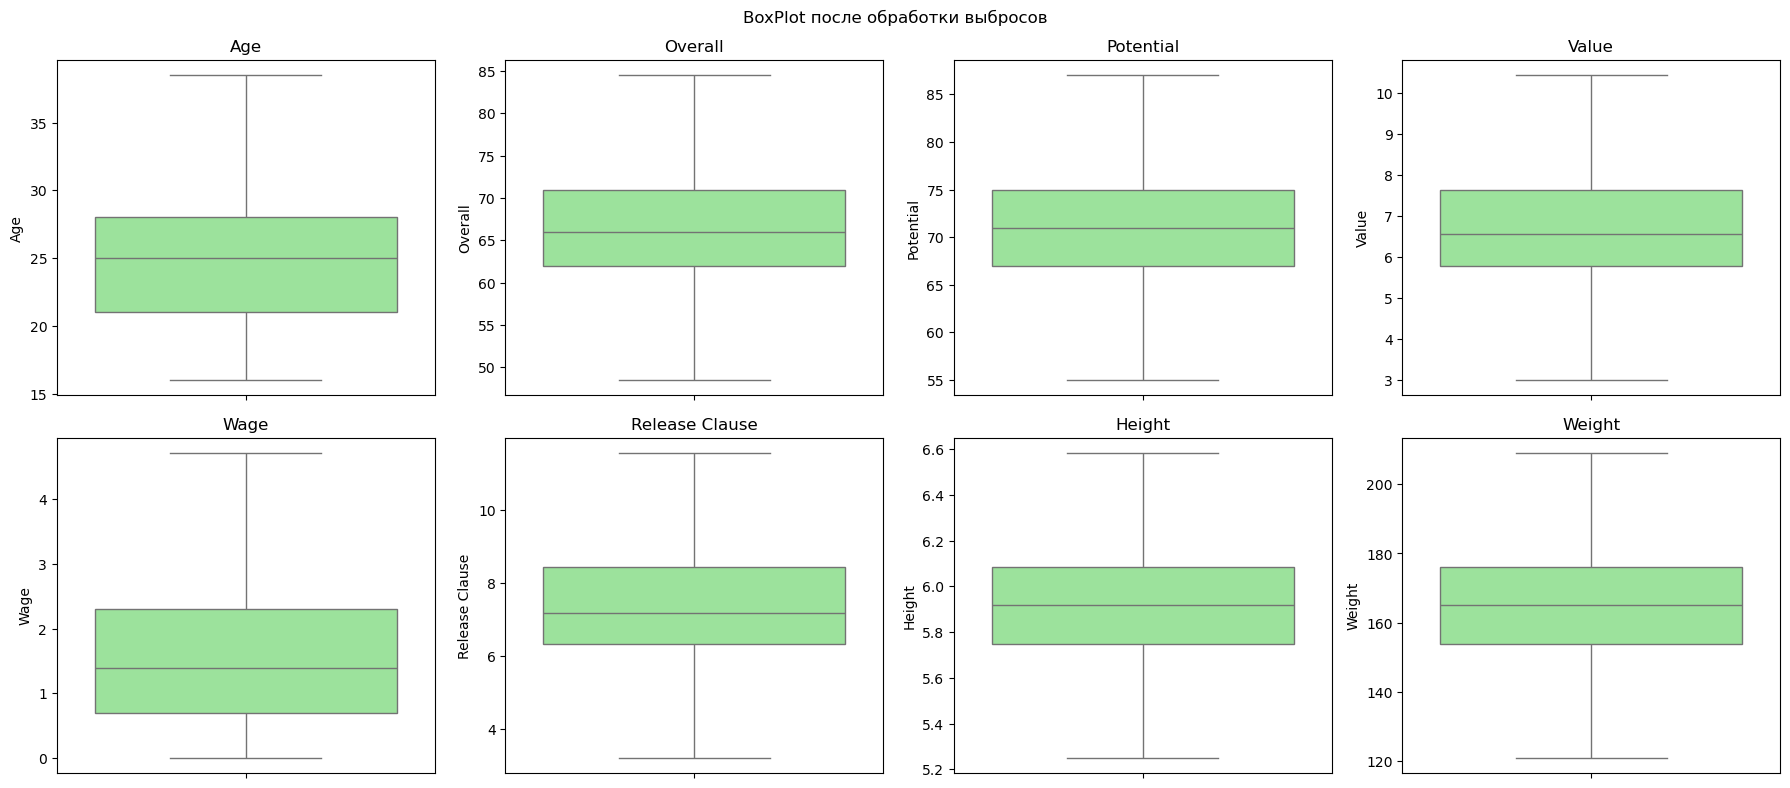

Выбросов по IQR после обработки:
Age: 0
Overall: 0
Potential: 0
Value: 0
Wage: 0
Release Clause: 0
Height: 0
Weight: 0


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.suptitle('BoxPlot после обработки выбросов')
plt.tight_layout()
plt.show()

print('Выбросов по IQR после обработки:')
for col in num_cols:
    lo, hi = iqr_bounds(df[col])
    print(f'{col}: {((df[col] < lo) | (df[col] > hi)).sum()}')

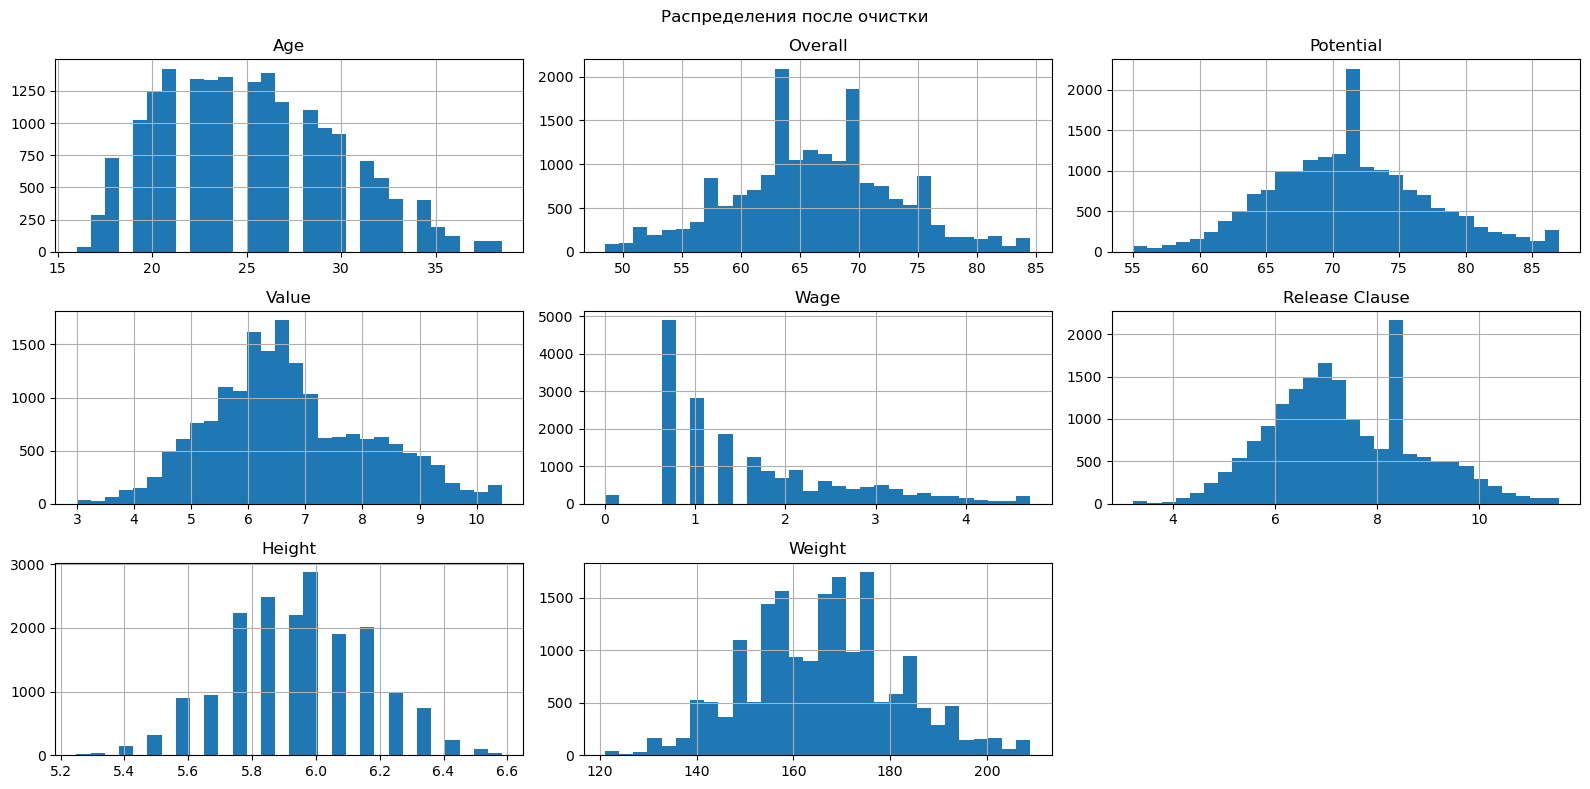

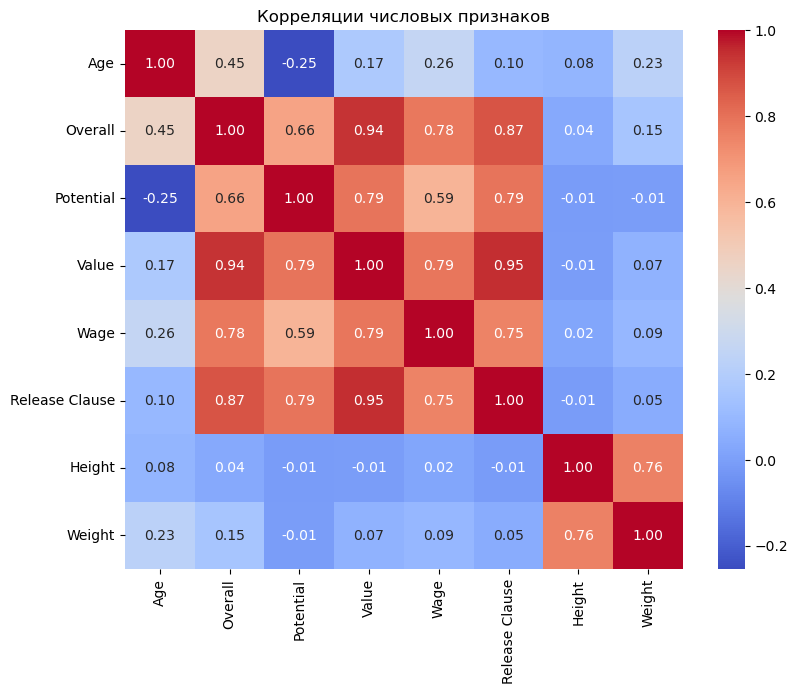

In [15]:
df[num_cols].hist(bins=30, figsize=(16, 8))
plt.suptitle('Распределения после очистки')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции числовых признаков')
plt.show()

## Генерация признаков и кодирование категориальных данных

In [12]:
# Данные соответствуют FIFA 19 (2018/2019), поэтому опорный год = 2018
REF_YEAR = 2018

df['Potential_Gap'] = df['Potential'] - df['Overall']                    # запас роста
df['Years_In_Club'] = (REF_YEAR - df['Joined']).clip(lower=0)            # стаж в клубе
df['Contract_Years'] = (df['Contract Valid Until'] - REF_YEAR).clip(lower=0)  # лет до конца контракта
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 21, 26, 31, 100], labels=['Young', 'Prime', 'Experienced', 'Veteran'])

df[['Name', 'Potential_Gap', 'Years_In_Club', 'Contract_Years', 'Age_Group']].head()

,Name,Potential_Gap,Years_In_Club,Contract_Years,Age_Group
0,L. Messi,2.5,14,3.0,Experienced
1,Cristiano Ronaldo,2.5,0,4.0,Veteran
2,Neymar Jr,2.5,1,4.0,Prime
3,De Gea,2.5,7,2.0,Experienced
4,K. De Bruyne,2.5,3,5.0,Experienced


In [16]:
df['Is_Free_Agent'] = (df['Club'] == 'Free Agent').astype(int)
df['Is_Right_Foot'] = (df['Preferred Foot'] == 'Right').astype(int)
df['Is_Young'] = (df['Age'] <= 21).astype(int)
df['Is_Star'] = (df['Overall'] >= df['Overall'].quantile(0.9)).astype(int)

In [17]:
pos_map = {
    'GK': 'GK',
    'CB': 'DEF', 'LCB': 'DEF', 'RCB': 'DEF', 'LB': 'DEF', 'RB': 'DEF', 'LWB': 'DEF', 'RWB': 'DEF',
    'CM': 'MID', 'LCM': 'MID', 'RCM': 'MID', 'CDM': 'MID', 'LDM': 'MID', 'RDM': 'MID',
    'CAM': 'MID', 'LAM': 'MID', 'RAM': 'MID', 'LM': 'MID', 'RM': 'MID',
    'ST': 'FWD', 'LS': 'FWD', 'RS': 'FWD', 'CF': 'FWD', 'LF': 'FWD', 'RF': 'FWD',
    'LW': 'FWD', 'RW': 'FWD'
}
df['Position_Group'] = df['Position'].map(pos_map).fillna('Other')

# Nationality имеет много категорий: оставляем топ-10, остальные объединяем в Other
top_nat = df['Nationality'].value_counts().head(10).index
df['Nationality_Top'] = df['Nationality'].where(df['Nationality'].isin(top_nat), 'Other')

df = pd.get_dummies(df, columns=['Position_Group', 'Age_Group', 'Nationality_Top'],
                    prefix=['Pos', 'AgeG', 'Nat'], dtype=int)

df = df.drop(columns=['Nationality', 'Club', 'Position'])
print(df.shape)
df.head()

(18207, 41)


,ID,Name,Age,Overall,Potential,Value,Wage,Preferred Foot,International Reputation,Skill Moves,...,Nat_Brazil,Nat_Colombia,Nat_England,Nat_France,Nat_Germany,Nat_Italy,Nat_Japan,Nat_Netherlands,Nat_Other,Nat_Spain
0,158023,L. Messi,31.0,84.5,87,10.445076,4.716742,Left,5.0,4.0,...,0,0,0,0,0,0,0,0,0,0
1,20801,Cristiano Ronaldo,33.0,84.5,87,10.445076,4.716742,Right,5.0,5.0,...,0,0,0,0,0,0,0,0,1,0
2,190871,Neymar Jr,26.0,84.5,87,10.445076,4.716742,Right,5.0,5.0,...,1,0,0,0,0,0,0,0,0,0
3,193080,De Gea,27.0,84.5,87,10.445076,4.716742,Right,4.0,1.0,...,0,0,0,0,0,0,0,0,0,1
4,192985,K. De Bruyne,27.0,84.5,87,10.445076,4.716742,Right,4.0,4.0,...,0,0,0,0,0,0,0,0,1,0


## 4. Масштабирование признаков
Масштабируем только непрерывные и порядковые признаки. Бинарные (0/1) и OHE-столбцы не трогаем.
Стандартизация (z-score): z = (x - mean) / std.
Нормализация (Min-Max): x' = (x - min) / (max - min).

In [19]:
scale_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause',
              'Height', 'Weight', 'International Reputation', 'Skill Moves',
              'Potential_Gap', 'Years_In_Club', 'Contract_Years']

# Стандартизация
df_std = df.copy()
df_std[scale_cols] = (df[scale_cols] - df[scale_cols].mean()) / df[scale_cols].std()

# Нормализация
df_mm = df.copy()
rng = df[scale_cols].max() - df[scale_cols].min()
df_mm[scale_cols] = (df[scale_cols] - df[scale_cols].min()) / rng.replace(0, 1)

print('Стандартизация: mean ≈ 0, std ≈ 1')
display(df_std[scale_cols].describe().loc[['mean', 'std']].round(3))
print('Нормализация: min = 0, max = 1')
display(df_mm[scale_cols].describe().loc[['min', 'max']].round(3))

Стандартизация: mean ≈ 0, std ≈ 1


,Age,Overall,Potential,Value,Wage,Release Clause,Height,Weight,International Reputation,Skill Moves,Potential_Gap,Years_In_Club,Contract_Years
mean,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Нормализация: min = 0, max = 1


,Age,Overall,Potential,Value,Wage,Release Clause,Height,Weight,International Reputation,Skill Moves,Potential_Gap,Years_In_Club,Contract_Years
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


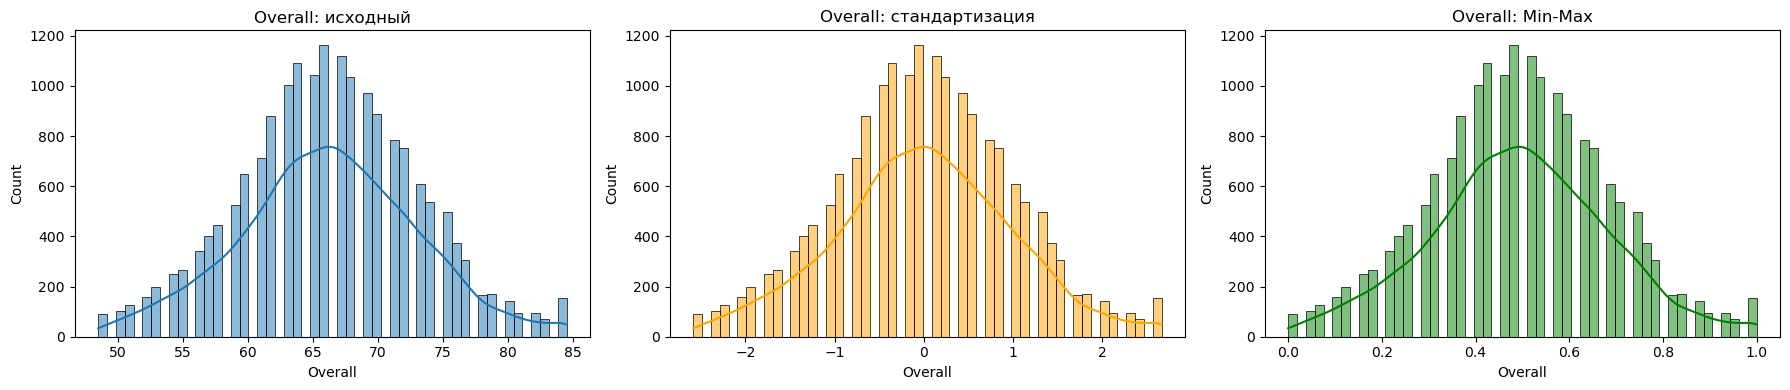

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['Overall'], kde=True, ax=axes[0]).set_title('Overall: исходный')
sns.histplot(df_std['Overall'], kde=True, ax=axes[1], color='orange').set_title('Overall: стандартизация')
sns.histplot(df_mm['Overall'], kde=True, ax=axes[2], color='green').set_title('Overall: Min-Max')
plt.tight_layout()
plt.show()

## Выводы
- Пропуски найдены в 5 столбцах. Они заполнены по смыслу: `Club` значением "Free Agent", числовые признаки медианой или модой.
- Выбросы в денежных признаках устранены логарифмированием и ограничением по IQR, в остальных признаках ограничением по IQR. BoxPlot и heatmap подтвердили, что пропусков нет, а выбросов практически нет.
- Созданы признаки `Potential_Gap`, `Years_In_Club`, `Contract_Years`, `Value_to_Wage`, `Age_Group`. Использованы бинаризация и OHE. Стандартизация и Min-Max выполнены только для непрерывных признаков.